In [28]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATConv, global_mean_pool
from torch.optim.lr_scheduler import StepLR, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import os

In [29]:
# Physical constants
M_TAU = 1.77686  # Tau mass in GeV
M_PI = 0.13957  # Charged pion mass in GeV
M_NU = 0.0      # Approximate massless neutrino

# Hyperparameters
NUM_EPOCHS = 100
BATCH_SIZE = 64
HIDDEN_DIM = 64
RANDOME_STATE = 42
LEARNING_RATE = 0.01
SCHEDULER_STEP_SIZE = 20
SCHEDULER_GAMMA = 0.75
TEST_SPLIT = 0.2
VALIDATION_SPLIT = 0.1

Feature normalization complete.


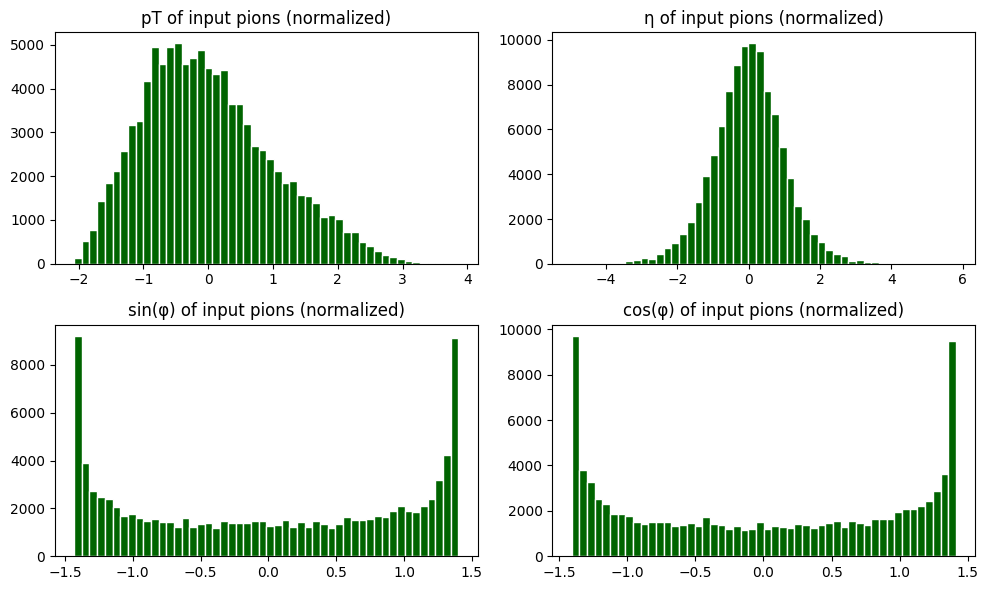

In [ ]:
# Preprocessing
# Create directory for plots
os.makedirs('gnn_plots', exist_ok=True)

# Load data
df = pd.read_csv('/home/zfang31/tau-decay-ml/data/reco_alldata.csv')
df_gen = pd.read_csv('/home/zfang31/tau-decay-ml/data/gen_alldata.csv')

# Extract pion features and transform
def preprocess_pions(df):
    pTs = df[['pi1_pt', 'pi2_pt', 'pi3_pt']].values
    etas = df[['pi1_eta', 'pi2_eta', 'pi3_eta']].values
    phis = df[['pi1_phi', 'pi2_phi', 'pi3_phi']].values

    vis_tau_pT = pTs.sum(axis=1, keepdims=True)  # shape: (N, 1)
    norm_pT = pTs / vis_tau_pT  # normalize pT_i / (pT_1 + pT_2 + pT_3)

    sin_phis = np.sin(phis)
    cos_phis = np.cos(phis)

    features = np.stack([norm_pT, etas, sin_phis, cos_phis], axis=2)
    return features, vis_tau_pT.squeeze()

X_raw, vis_tau_pT_all = preprocess_pions(df_gen)  # X_raw shape: (N_events, 3_nodes, 4_features)

# Input normalization
X_flat = X_raw.reshape(-1, 4)
X_scaler = StandardScaler()
X_normalized = X_scaler.fit_transform(X_flat).reshape(-1, 3, 4)

# Target variables
phi = df['neu_phi'].values
neu_pT = df['neu_pt'].values
log_pT = np.log(df['neu_pt'].values + 1)
norm_neu_pT = neu_pT / vis_tau_pT_all
Y = np.stack([
    log_pT,
    df['neu_eta'].values,
    np.sin(phi),
    np.cos(phi)
], axis=1)

# Train/val/test split
X_trainval, X_test, Y_trainval, Y_test, vis_tau_pT_trainval, vis_tau_pT_test = train_test_split(
    X_normalized, Y, vis_tau_pT_all, test_size=TEST_SPLIT, random_state=RANDOME_STATE)

X_train, X_val, Y_train, Y_val, vis_tau_pT_train, vis_tau_pT_val = train_test_split(
    X_trainval, Y_trainval, vis_tau_pT_trainval, test_size=VALIDATION_SPLIT, random_state=RANDOME_STATE)

# # Extract tau mass for each event
# tau_mass_all = df['tau_m'].values
# tau_mass_trainval, tau_mass_test = train_test_split(tau_mass_all, test_size=TEST_SPLIT, random_state=RANDOME_STATE)
# tau_mass_train, tau_mass_val = train_test_split(tau_mass_trainval, test_size=VALIDATION_SPLIT, random_state=RANDOME_STATE)

# Visualize normalized features
feature_labels = ['pT', 'η', 'sin(φ)', 'cos(φ)']
X_vis = X_train.reshape(-1, 4)
plt.figure(figsize=(10, 6))
for i in range(4):
    plt.subplot(2, 2, i+1)
    plt.hist(X_vis[:, i], bins=50, color='darkgreen', edgecolor='white')
    plt.title(f'{feature_labels[i]} of input pions (normalized)')
plt.tight_layout()
plt.savefig('gnn_plots/input_histograms_normalized.png')
print("Feature normalization complete.")

In [31]:
# Graph dataset class
class TauDecayGraphDataset(Dataset):
    def __init__(self, X, Y, vis_tau_pt):
        super().__init__()
        self.X = X
        self.Y = Y
        self.vis_tau_pt = vis_tau_pt

    def len(self):
        return len(self.X)

    def get(self, idx):
        x = torch.tensor(self.X[idx], dtype=torch.float32)
        y = torch.tensor(self.Y[idx], dtype=torch.float32).unsqueeze(0)
        vis_pt = torch.tensor(self.vis_tau_pt[idx], dtype=torch.float32).unsqueeze(0)
        edge_index = torch.tensor([[0, 1, 0, 2, 1, 2],
                                   [1, 0, 2, 0, 2, 1]], dtype=torch.long)
        return Data(x=x, edge_index=edge_index, y=y, vis_tau_pt=vis_pt)

train_dataset = TauDecayGraphDataset(X_train, Y_train, vis_tau_pT_train)
val_dataset = TauDecayGraphDataset(X_val, Y_val, vis_tau_pT_val)
test_dataset = TauDecayGraphDataset(X_test, Y_test, vis_tau_pT_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=len(val_dataset))
test_loader = DataLoader(test_dataset, batch_size=len(test_dataset))

In [32]:
# Model
class TauGNN(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=HIDDEN_DIM, output_dim=4):
        super().__init__()

        self.conv1 = GATConv(input_dim, hidden_dim, heads=8, concat=True)
        self.conv2 = GATConv(hidden_dim * 8, hidden_dim, heads=1, concat=True)

        self.fc1 = nn.Linear(hidden_dim, 32)
        self.fc2 = nn.Linear(32, output_dim)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = global_mean_pool(x, batch)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

In [33]:
# Loss function
def custom_loss(pred, target, pion_features, vis_tau_pT, w_mass=0.5):
    w_reco = 1 - w_mass
    
    # Reconstruction loss (sum of MSEs)
    pT_loss = F.mse_loss(pred[:, 0], target[:, 0])
    eta_loss = F.mse_loss(pred[:, 1], target[:, 1])
    sin_phi_loss = F.mse_loss(pred[:, 2], target[:, 2])
    cos_phi_loss = F.mse_loss(pred[:, 3], target[:, 3])

    recon_loss = pT_loss + eta_loss + sin_phi_loss + cos_phi_loss
    # print(f"pT Loss: {pT_loss.item():.4f}, eta Loss: {eta_loss.item():.4f}, sin(phi) Loss: {sin_phi_loss.item():.4f}, cos(phi) Loss: {cos_phi_loss.item():.4f}")

    # Mass-constraint loss (dimensionless)
    # Decode neutrino momentum
    neu_pT  = torch.exp(pred[:, 0]) - 1
    # neu_pT = pred[:, 0] * vis_tau_pT.squeeze()
    neu_eta = pred[:, 1]
    neu_phi = torch.atan2(pred[:, 2], pred[:, 3])

    neu_px = neu_pT * torch.cos(neu_phi)
    neu_py = neu_pT * torch.sin(neu_phi)
    neu_pz = neu_pT * torch.sinh(neu_eta)
    neu_E  = torch.sqrt(neu_px**2 + neu_py**2 + neu_pz**2 + M_NU**2)

    # Decode pion four‑vectors
    # Invert normalization to input pion features
    B = pion_features.shape[0]
    pion_features_flat = pion_features.view(B * 3, 4).cpu().numpy()
    pion_raw_flat = X_scaler.inverse_transform(pion_features_flat)
    pion_raw = torch.tensor(pion_raw_flat, dtype=torch.float32, device=pred.device).view(B, 3, 4) 

    # Decode pion momenta
    pi_pT = pion_raw[:, :, 0] * vis_tau_pT.unsqueeze(1)
    pi_eta  = pion_raw[:, :, 1]
    pi_phi  = torch.atan2(pion_raw[:, :, 2], pion_raw[:, :, 3])

    pi_px = pi_pT * torch.cos(pi_phi)
    pi_py = pi_pT * torch.sin(pi_phi)
    pi_pz = pi_pT * torch.sinh(pi_eta)
    pi_E  = torch.sqrt(pi_px**2 + pi_py**2 + pi_pz**2 + M_PI**2)

    # Event‑by‑event tau four‑vector = Σ pions + ν
    tot_px = pi_px.sum(dim=1) + neu_px
    tot_py = pi_py.sum(dim=1) + neu_py
    tot_pz = pi_pz.sum(dim=1) + neu_pz
    tot_E  = pi_E .sum(dim=1) + neu_E

    m_tau_reco_sq = tot_E**2 - (tot_px**2 + tot_py**2 + tot_pz**2)

    # Dimensionless squared relative deviation from tau_mass^2
    mass_loss = torch.mean((torch.abs(m_tau_reco_sq - M_TAU**2) / (M_TAU**2)))

    # Weighted total loss
    total_loss = w_reco * recon_loss + w_mass * mass_loss
    # print(f"Reconstruction Loss: {recon_loss.item():.4f}, Mass Loss: {mass_loss.item():.4f}")
    return total_loss

In [34]:
# Training
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = TauGNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = StepLR(optimizer, step_size=SCHEDULER_STEP_SIZE, gamma=SCHEDULER_GAMMA)
# scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
train_loss_history = []
val_loss_history = []

model.train()
for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch)
        loss = custom_loss(out, batch.y.squeeze(1), batch.x.view(-1, 3, 4), batch.vis_tau_pt)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    avg_train_loss = total_loss / len(train_loader)
    train_loss_history.append(avg_train_loss)

    # Validation
    model.eval()
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            out = model(batch)
            val_loss = custom_loss(out, batch.y.squeeze(1), batch.x.view(-1, 3, 4), batch.vis_tau_pt).item()
    val_loss_history.append(val_loss)

    scheduler.step()
    # scheduler.step(val_loss)
    print(f"Epoch {epoch+1:3d}, Train Loss: {avg_train_loss:.4f}, Val Loss: {val_loss:.4f}, LR: {scheduler.get_last_lr()[0]:.6f}")

Epoch   1, Train Loss: 0.0955, Val Loss: 0.0591, LR: 0.010000
Epoch   2, Train Loss: 0.0464, Val Loss: 0.0451, LR: 0.010000
Epoch   3, Train Loss: 0.0374, Val Loss: 0.0412, LR: 0.010000
Epoch   4, Train Loss: 0.0340, Val Loss: 0.0312, LR: 0.010000
Epoch   5, Train Loss: 0.0302, Val Loss: 0.0341, LR: 0.010000
Epoch   6, Train Loss: 0.0296, Val Loss: 0.0287, LR: 0.010000
Epoch   7, Train Loss: 0.0271, Val Loss: 0.0241, LR: 0.010000
Epoch   8, Train Loss: 0.0323, Val Loss: 0.0236, LR: 0.010000
Epoch   9, Train Loss: 0.0249, Val Loss: 0.0245, LR: 0.010000
Epoch  10, Train Loss: 0.0272, Val Loss: 0.0349, LR: 0.010000
Epoch  11, Train Loss: 0.0243, Val Loss: 0.0239, LR: 0.010000
Epoch  12, Train Loss: 0.0252, Val Loss: 0.0220, LR: 0.010000
Epoch  13, Train Loss: 0.0271, Val Loss: 0.0287, LR: 0.010000
Epoch  14, Train Loss: 0.0235, Val Loss: 0.0247, LR: 0.010000
Epoch  15, Train Loss: 0.0256, Val Loss: 0.0262, LR: 0.010000
Epoch  16, Train Loss: 0.0240, Val Loss: 0.0209, LR: 0.010000
Epoch  1

In [35]:
# Evaluation
model.eval()
predictions, truths = [], []
count = 0

for name, param in model.named_parameters():
    if param.requires_grad:
        # print(f'Layer: {name} | Size: {param.size()} | Number of parameters: {param.numel()}')
        count = count + param.numel()
print("Total param count:" + str(count))

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out = model(batch)
        predictions.append(out.cpu())
        truths.append(batch.y.cpu())

predictions = torch.cat(predictions, dim=0).numpy()
truths = torch.cat(truths, dim=0).numpy()

# Reconstruct pT from log(pT)
# pred_pT = predictions[:, 0] * vis_tau_pT_test
# true_pT = truths[:, 0] * vis_tau_pT_test
pred_pT = np.exp(predictions[:, 0]) - 1
true_pT = np.exp(truths[:, 0]) - 1

pred_eta, true_eta = predictions[:, 1], truths[:, 1]

# Reconstruct phi from sin/cos
pred_phi = np.arctan2(predictions[:, 2], predictions[:, 3])
true_phi = np.arctan2(truths[:, 2], truths[:, 3])

Total param count:38756


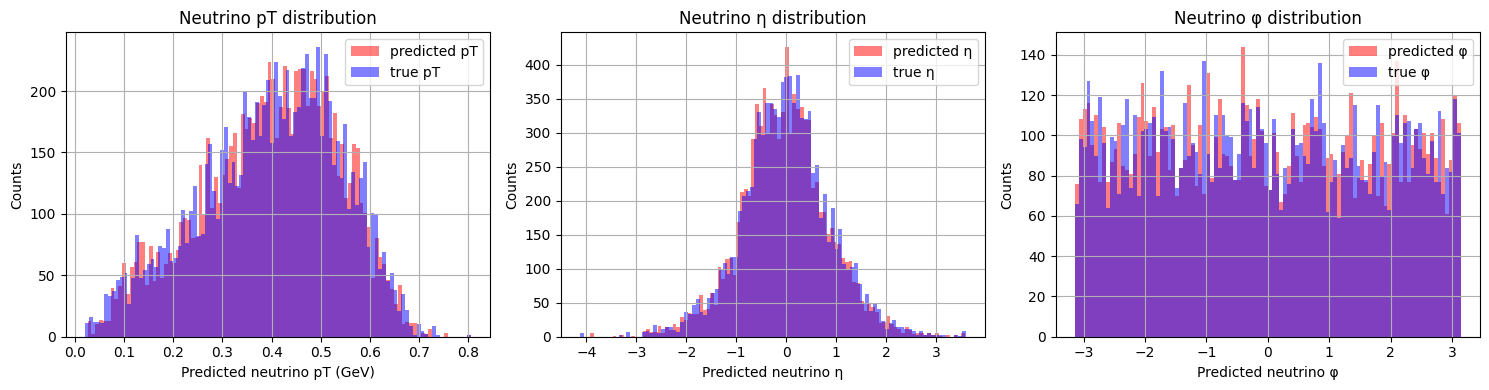

In [43]:
# Plot predicted neutrino distributions
plt.figure(figsize=(15, 4))
# Neutrino pT
plt.subplot(1, 3, 1)
plt.hist(pred_pT, bins=100, alpha=0.5, label='predicted pT', color='red')
plt.hist(true_pT, bins=100, alpha=0.5, label='true pT', color='blue')
plt.legend(loc='upper right')
plt.xlabel('Predicted neutrino pT (GeV)')
plt.ylabel('Counts')
plt.title('Neutrino pT distribution')
plt.grid(True)
# Neutrino eta
plt.subplot(1, 3, 2)
plt.hist(pred_eta, bins=100, alpha=0.5, label='predicted η', color='red')
plt.hist(true_eta, bins=100, alpha=0.5, label='true η', color='blue')
plt.legend(loc='upper right')
plt.xlabel('Predicted neutrino η')
plt.ylabel('Counts')
plt.title('Neutrino η distribution')
plt.grid(True)
# Neutrino phi
plt.subplot(1, 3, 3)
plt.hist(pred_phi, bins=100, range=(-np.pi, np.pi), alpha=0.5, label='predicted φ', color='red')
plt.hist(true_phi, bins=100, range=(-np.pi, np.pi), alpha=0.5, label='true φ', color='blue')
plt.legend(loc='upper right')
plt.xlabel('Predicted neutrino φ')
plt.ylabel('Counts')
plt.title('Neutrino φ distribution')
plt.grid(True)

plt.tight_layout()
plt.savefig('gnn_plots/neu_distributions.png')
plt.show()

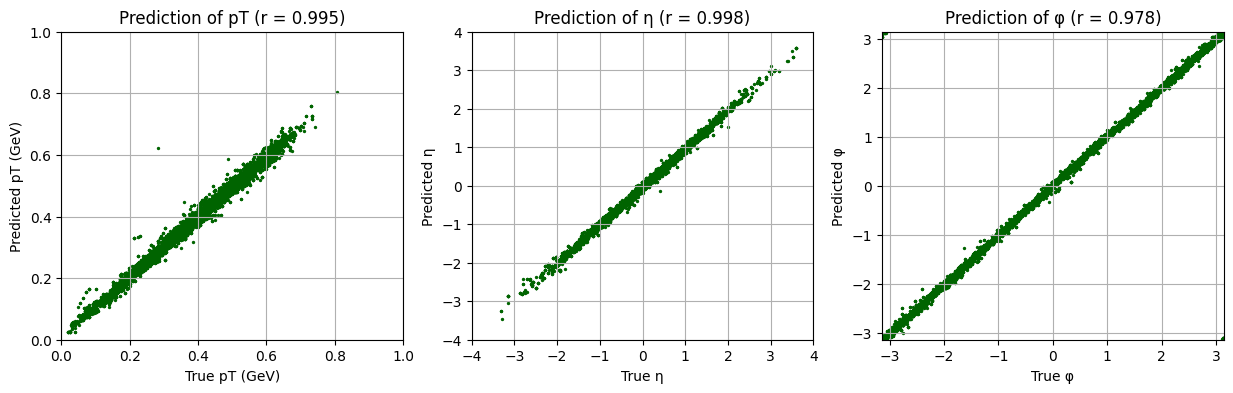

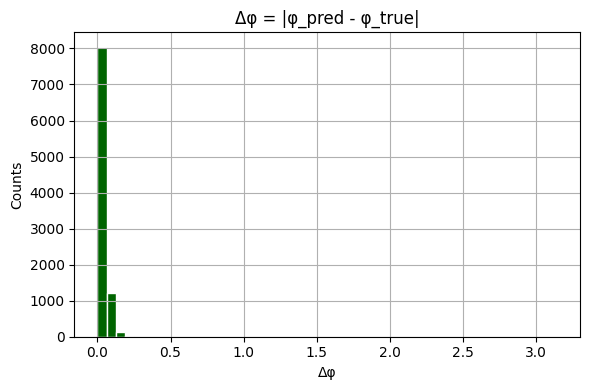

In [41]:
# Plot predictions
plt.figure(figsize=(15, 4))
# Neutrino pT
r_pT, _ = pearsonr(true_pT, pred_pT)
plt.subplot(1, 3, 1)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.scatter(true_pT, pred_pT, s=2, color='darkgreen')
plt.title(f'Prediction of pT (r = {r_pT:.3f})')
plt.xlabel('True pT (GeV)')
plt.ylabel('Predicted pT (GeV)')
plt.grid(True)
plt.savefig('gnn_plots/pt_plot_gnn.png')
# Neutrino eta
r_eta, _ = pearsonr(true_eta, pred_eta)
plt.subplot(1, 3, 2)
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.scatter(true_eta, pred_eta, s=2, color='darkgreen')
plt.title(f'Prediction of η (r = {r_eta:.3f})')
plt.xlabel('True η')
plt.ylabel('Predicted η')
plt.grid(True)
plt.savefig('gnn_plots/eta_plot_gnn.png')
# Neutrino phi
r_phi, _ = pearsonr(true_phi, pred_phi)
plt.subplot(1, 3, 3)
plt.xlim(-np.pi, np.pi)
plt.ylim(-np.pi, np.pi)
plt.scatter(true_phi, pred_phi, s=2, color='darkgreen')
plt.title(f'Prediction of φ (r = {r_phi:.3f})')
plt.xlabel('True φ')
plt.ylabel('Predicted φ')
plt.grid(True)
plt.savefig('gnn_plots/phi_plot_gnn.png')

# Histogram of Δφ
dphi = abs(pred_phi - true_phi)
plt.figure(figsize=(6, 4))
plt.hist(dphi, bins=50, range=(0, np.pi), color='darkgreen', edgecolor='white')
plt.title('Δφ = |φ_pred - φ_true|')
plt.xlabel('Δφ')
plt.ylabel('Counts')
plt.grid(True)
plt.tight_layout()
plt.savefig('gnn_plots/dphi_histogram.png')

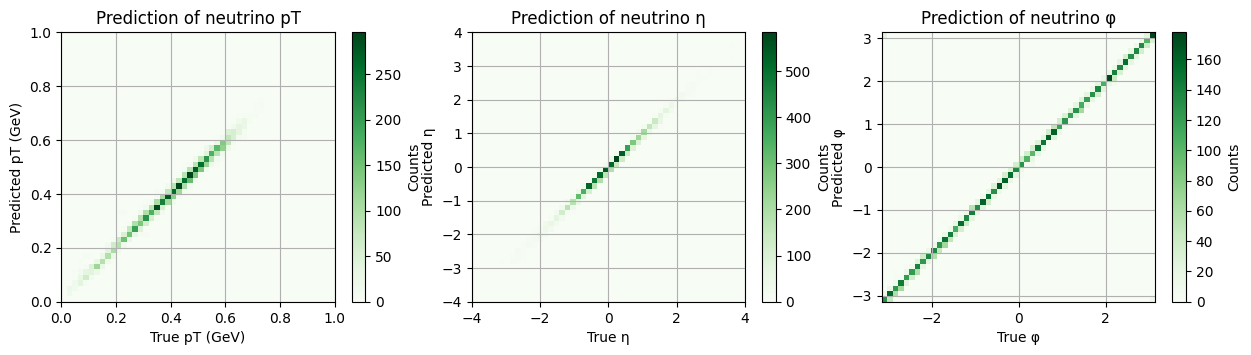

In [42]:
# Plot heatmaps
plt.figure(figsize=(15, 3.5))
# Neutrino pT
plt.subplot(1, 3, 1)
plt.hist2d(true_pT, pred_pT, bins=50, range=[[0, 1], [0, 1]], cmap='Greens')
plt.colorbar(label='Counts')
plt.title('Prediction of neutrino pT')
plt.xlabel('True pT (GeV)')
plt.ylabel('Predicted pT (GeV)')
plt.grid(True)
plt.savefig('gnn_plots/pt_heatmap_gnn.png')
# Neutrino eta
plt.subplot(1, 3, 2)
plt.hist2d(true_eta, pred_eta, bins=50, range=[[-4, 4], [-4, 4]], cmap='Greens')
plt.colorbar(label='Counts')
plt.title(f'Prediction of neutrino η')
plt.xlabel('True η')
plt.ylabel('Predicted η')
plt.grid(True)
plt.savefig('gnn_plots/eta_heatmap_gnn.png')
# Neutrino phi
plt.subplot(1, 3, 3)
plt.hist2d(true_phi, pred_phi, bins=50, range=[[-np.pi, np.pi], [-np.pi, np.pi]], cmap='Greens')
plt.colorbar(label='Counts')
plt.title(f'Prediction of neutrino φ')
plt.xlabel('True φ')
plt.ylabel('Predicted φ')
plt.grid(True)
plt.savefig('gnn_plots/phi_heatmap_gnn.png')

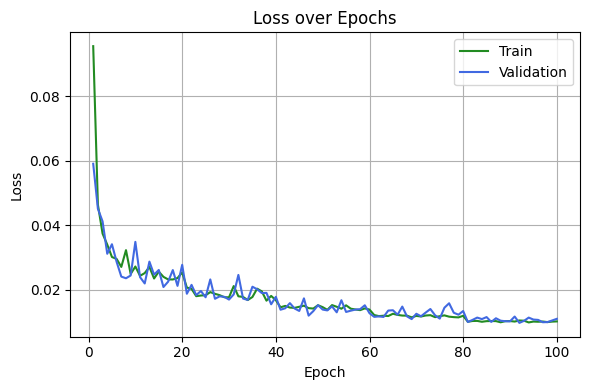

In [39]:
# Plot losses
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(train_loss_history)+1), train_loss_history, color='forestgreen', label='Train')
plt.plot(range(1, len(val_loss_history)+1), val_loss_history, color='royalblue', label='Validation')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('gnn_plots/loss_plot_gnn.png')
plt.show()

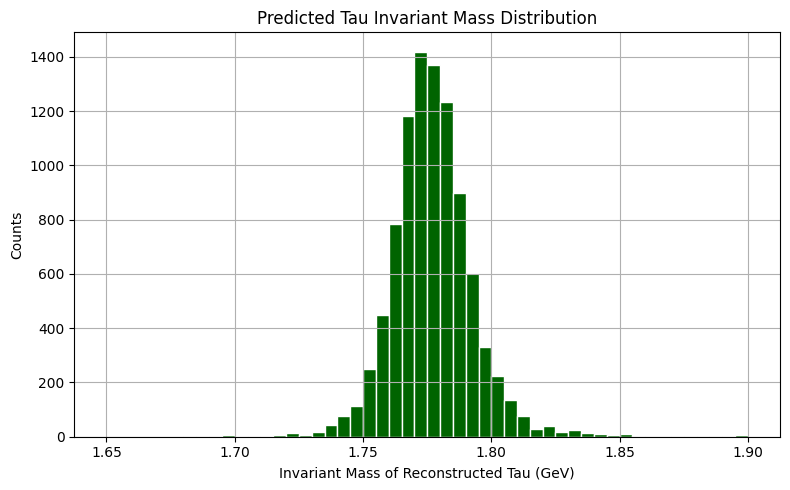

In [45]:
# Plot invariant mass of reconstructed tau
# Function to compute 4-vector
def four_vector(pt, eta, phi, mass):
    px = pt * np.cos(phi)
    py = pt * np.sin(phi)
    pz = pt * np.sinh(eta)
    E = np.sqrt(px**2 + py**2 + pz**2 + mass**2)
    return np.stack([E, px, py, pz], axis=1)

# Reproduce the raw pion feature split to match X_test
pion_raw_features = df_gen[['pi1_pt', 'pi2_pt', 'pi3_pt',
                            'pi1_eta', 'pi2_eta', 'pi3_eta',
                            'pi1_phi', 'pi2_phi', 'pi3_phi']]

_, pion_raw_test = train_test_split(pion_raw_features, test_size=TEST_SPLIT, random_state=42)
pion_raw_test = pion_raw_test.reset_index(drop=True)

# Extract raw pion pt, eta, phi from test set
pi1_pT, pi2_pT, pi3_pT = pion_raw_test['pi1_pt'].values, pion_raw_test['pi2_pt'].values, pion_raw_test['pi3_pt'].values
pi1_eta, pi2_eta, pi3_eta = pion_raw_test['pi1_eta'].values, pion_raw_test['pi2_eta'].values, pion_raw_test['pi3_eta'].values
pi1_phi, pi2_phi, pi3_phi = pion_raw_test['pi1_phi'].values, pion_raw_test['pi2_phi'].values, pion_raw_test['pi3_phi'].values

# Compute 4-vectors
pi1 = four_vector(pi1_pT, pi1_eta, pi1_phi, M_PI)
pi2 = four_vector(pi2_pT, pi2_eta, pi2_phi, M_PI)
pi3 = four_vector(pi3_pT, pi3_eta, pi3_phi, M_PI)

# Get predicted neutrino 4-vector
neu = four_vector(pred_pT, pred_eta, pred_phi, M_NU)

# Total tau 4-vector = pi1 + pi2 + pi3 + neu
tau_total = pi1 + pi2 + pi3 + neu
E, px, py, pz = tau_total.T
m_tau_pred = np.sqrt(np.maximum(E**2 - (px**2 + py**2 + pz**2), 0))

# Plot histogram
plt.figure(figsize=(8, 5))
plt.hist(m_tau_pred, bins=50, range=(1.65, 1.9), color='darkgreen', edgecolor='white')
plt.xlabel("Invariant Mass of Reconstructed Tau (GeV)")
plt.ylabel("Counts")
plt.title("Predicted Tau Invariant Mass Distribution")
plt.grid(True)
plt.tight_layout()
plt.savefig('gnn_plots/tau_mass_predicted.png')